In [46]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import io
import datetime
import timeit
import os



stuCur = pd.read_csv("data/students_current.csv", na_values="Not Applicable")
stuExp = pd.read_csv("data/student_experience.csv", na_values="Not Applicable")
stuAlum = pd.read_csv("data/alumni.csv", na_values="Not Applicable")



In [47]:
catbyType = stuExp.groupby("experience_type").agg(
  records=("record_id","count"),
  students=("campus_id","nunique"),
  orgs=("organization","nunique"),
  avg_terms=("duration_terms","mean"),
  avg_hours=("hours_per_week", "mean"),
  pct_paid=("is_paid", lambda s: s.dropna().astype(bool).mean() * 100),
).round(1).sort_values("records", ascending=False)
catbyType

,records,students,orgs,avg_terms,avg_hours,pct_paid
experience_type,,,,,,
Student Organization,4176,3208,1,3.1,4.0,0.0
Internship,4106,3012,58,1.0,28.4,87.0
Hackathon,3259,1489,8,1.0,36.3,0.0
Certification,2845,1712,17,1.0,NaN,NaN
Campus Job,2080,2080,7,3.3,13.0,100.0
Undergraduate Research,954,954,7,2.4,10.2,63.7
Tutoring,715,715,4,2.5,7.1,100.0
Competitive Team,700,700,1,2.0,8.7,0.0
Co-op,678,652,58,2.0,40.0,89.4


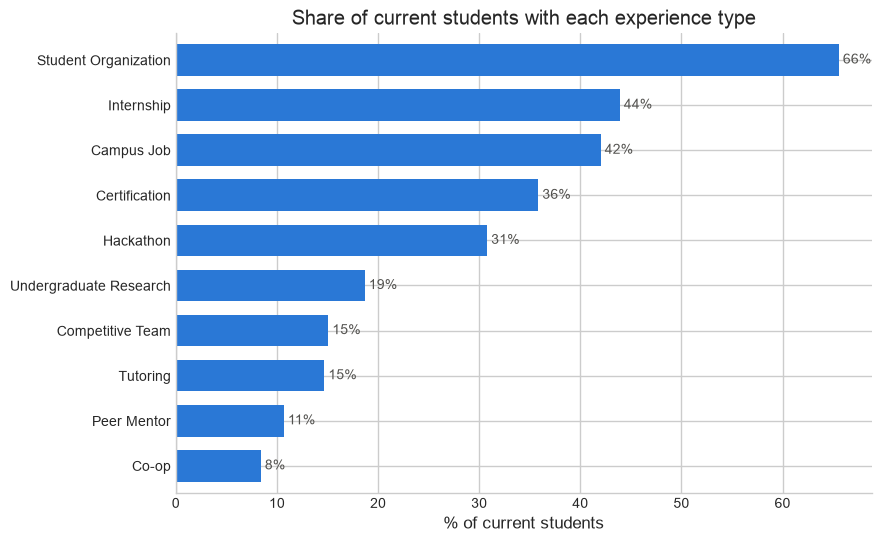

In [48]:
expCur = stuExp[stuExp["campus_id"].isin(stuCur["campus_id"])]
pctCur = expCur.groupby("experience_type")["campus_id"].nunique() / len(stuCur) * 100

ax = pctCur.sort_values().plot.barh(color="#2a78d6", figsize=(8, 5), width=0.7)
ax.bar_label(ax.containers[0], fmt="%.0f%%", padding=3, color="#52514e")
ax.set(xlabel="% of current students", ylabel="", title="Share of current students with each experience type")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

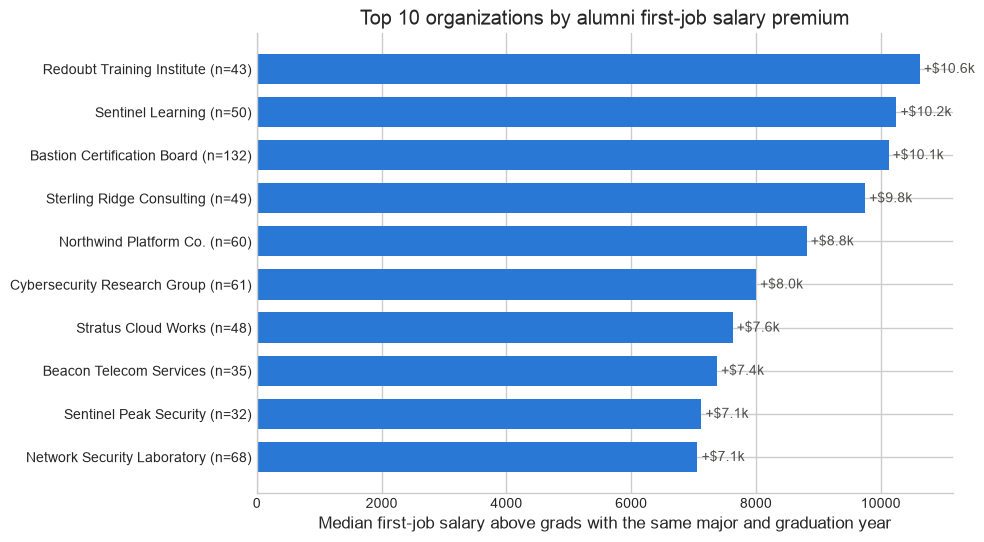

In [49]:
# alumni only; one row per person per organization, so repeat entries don't double-count
# sal_adj = first-job salary minus the median of grads with the same major and graduation year
sal = stuAlum["first_job_annual_salary_usd"]
stuAlum["sal_adj"] = sal - sal.groupby([stuAlum["major"], stuAlum["graduation_year"]]).transform("median")
expAlu = stuExp[stuExp["campus_id"].isin(stuAlum["campus_id"])].drop_duplicates(["campus_id", "organization"])
m = expAlu.merge(stuAlum[["campus_id", "sal_adj"]], on="campus_id")

orgRank = m.groupby("organization").agg(
    n=("sal_adj", "count"),          # alumni with a first-job salary
    premium=("sal_adj", "median"),
)
top10 = orgRank[orgRank["n"] >= 30].nlargest(10, "premium")
plotData = top10[::-1]   # reversed so #1 is on top

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([f"{o} (n={n})" for o, n in plotData["n"].items()], plotData["premium"], color="#2a78d6", height=0.7)
ax.bar_label(ax.containers[0], labels=[f"+${v/1000:.1f}k" for v in plotData["premium"]], padding=3, color="#52514e")
ax.set(xlabel="Median first-job salary above grads with the same major and graduation year",
       title="Top 10 organizations by alumni first-job salary premium")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

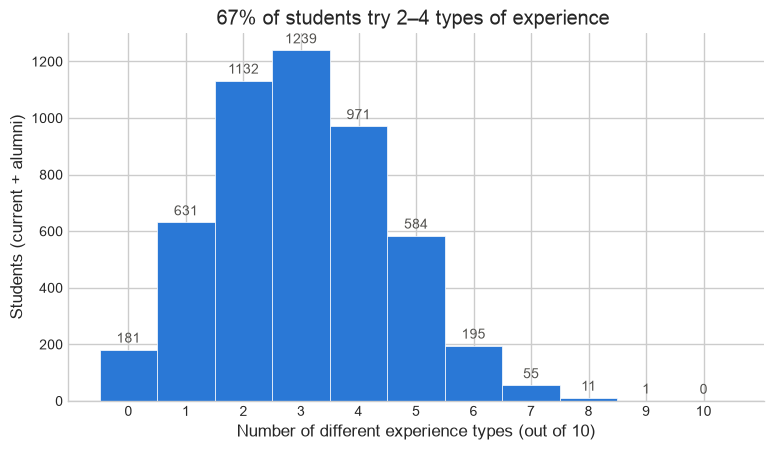

In [50]:
# breadth = distinct experience types per person; people with no experience rows count as 0
ids = pd.concat([stuCur["campus_id"], stuAlum["campus_id"]])
breadth = stuExp.groupby("campus_id")["experience_type"].nunique().reindex(ids, fill_value=0)
share = breadth.between(2, 4).mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(breadth, bins=np.arange(-0.5, 11.5), color="#2a78d6", edgecolor="white", linewidth=0.5)
ax.bar_label(ax.containers[0], fmt="%d", padding=3, color="#52514e")
ax.set(xticks=range(11),
       xlabel="Number of different experience types (out of 10)", ylabel="Students (current + alumni)",
       title=f"{share:.0f}% of students try 2–4 types of experience ")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

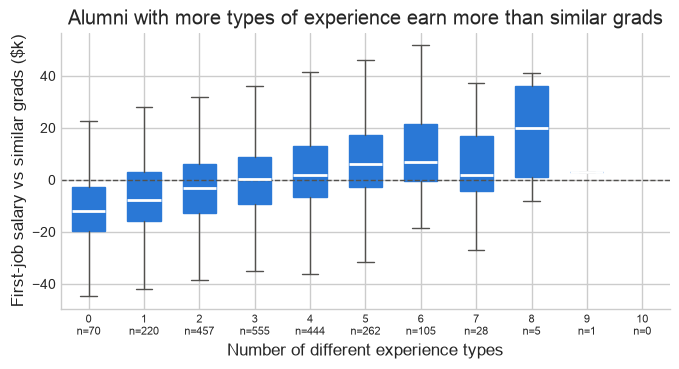

In [51]:
# alumni only; salary minus the median of grads with the same major and graduation year (fair comparison across majors and years)
sal = stuAlum["first_job_annual_salary_usd"]
adj = (sal - sal.groupby([stuAlum["major"], stuAlum["graduation_year"]]).transform("median")) / 1000
grp = stuAlum["campus_id"].map(breadth)
data = [adj[(grp == k) & adj.notna()] for k in range(11)]
labels = [f"{k}\nn={len(d)}" for k, d in enumerate(data)]

fig, ax = plt.subplots(figsize=(7, 3))
ax.boxplot(data, tick_labels=labels, widths=0.6, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor="#2a78d6", edgecolor="#2a78d6"), medianprops=dict(color="white", linewidth=2),
           whiskerprops=dict(color="#52514e"), capprops=dict(color="#52514e"))
ax.axhline(0, color="#52514e", linestyle="--", linewidth=1)
ax.tick_params(axis="x", labelsize=8)
ax.set(xlabel="Number of different experience types", ylabel="First-job salary vs similar grads ($k)",
       title="Alumni with more types of experience earn more than similar grads")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [52]:
stuAlum["sal_adj"] = sal - sal.groupby([stuAlum["major"], stuAlum["graduation_year"]]).transform("median")

m = (stuExp.drop_duplicates(["campus_id", "organization"])
           .merge(stuAlum[["campus_id", "sal_adj"]], on="campus_id"))   # inner join = alumni only
orgRank = m.groupby("organization").agg(n=("sal_adj", "count"), premium=("sal_adj", "median"))
top10 = orgRank[orgRank["n"] >= 30].nlargest(10, "premium")

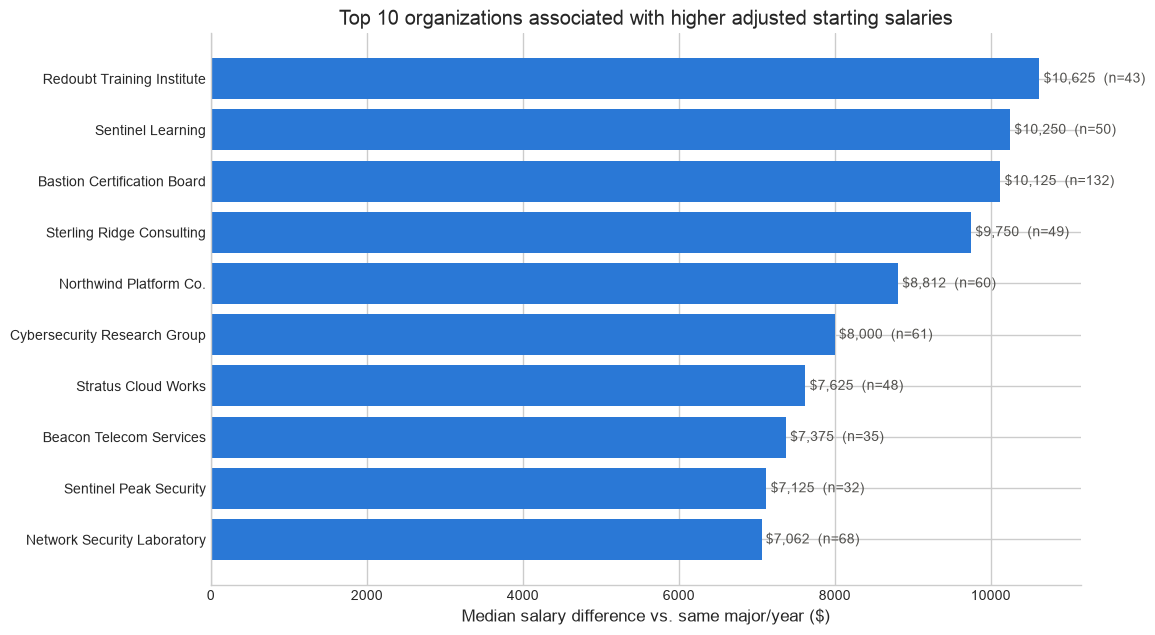

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))

plotData = top10.sort_values("premium")

ax.barh(
    plotData.index,
    plotData["premium"],
    color="#2a78d6"
)

labels = [
    f"${premium:,.0f}  (n={n})"
    for premium, n in zip(plotData["premium"], plotData["n"])
]

ax.bar_label(
    ax.containers[0],
    labels=labels,
    padding=3,
    color="#52514e"
)

ax.set(
    xlabel="Median salary difference vs. same major/year ($)",
    ylabel="",
    title="Top 10 organizations associated with higher adjusted starting salaries"
)

ax.spines[["top", "right"]].set_visible(False)

plt.show()